In [1]:
import numpy as np
from scipy.stats import cauchy
from scipy.signal import butter,filtfilt
import math 
import torch

import matplotlib.pyplot as plt
import matplotlib as mpl
import plotly
import pandas as pd
from scipy.ndimage import gaussian_filter1d


neuron_types = pd.read_csv('DG_CA2_Sub_CA3_CA1_EC_neuron_parameters06-30-2024_10_52_20.csv', delimiter=',')
neuron_param = neuron_types[neuron_types['Neuron Type'] == 'CA1 Basket']




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/sergejskorohod/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/sergejskorohod/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/sergejskorohod/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start

In [2]:
def TMsyn(r, norm, R, X, U, dt, tau_d, tau_r, tau_f, Uinc):

    # R - active, X - ready, U - utilized
    r*=norm
    
    # tau_d = 3.8314141705882356 
    # tau_r = 635.5365306862744 *0.5
    # tau_f = 15.095432365686278
    # Uinc = 0.2738522440196079


    tau1r = np.where(tau_d != tau_r, tau_d / (tau_d - tau_r), 1e-13)
    exp_tau_d = np.exp(-dt / tau_d)
    exp_tau_r = np.exp(-dt / tau_r)
    exp_tau_f = np.exp(-dt / tau_f)


    y_ = R * exp_tau_d
    x_ = 1 + (X - 1 + tau1r * U) * exp_tau_r - tau1r * U
    u_ = U * exp_tau_f

    released_mediator = U * x_ * r
    U = (u_ + Uinc * (1 - u_) * r)
    R = (y_ + released_mediator)
    X = (x_ - released_mediator)

    return R, X, U


In [ ]:
# Periodic steps of current, if needed
def Iext(t):
    period = 170
    width = 40
    ampl = -600
    start = 260
    k = (t-start)//period
    x = start + period*k
    if (t>x-width) and (t<x+width):
        I = np.random.normal(ampl, 50) #50
    else: I = np.random.normal(0, 50)
    if t<start: I = np.random.normal(0, 50)
    return I

# tmin = 0.0
# tmax = 1200 # msec
# dt = 0.001
# #steps = ((tmax - tmin)/dt) // 1 
# t = np.arange(tmin, tmax, dt)
# I = list(map(Iext, t))

# plt.plot(t, I)
# plt.show()

In [22]:
# pi = 3.141517281728

# a=1
# b=95
# c=2200

# alpha = 0.1
# beta = 1.2

# u_jump = 0

# Cm = 40

# v_peak = 400
# v_reset = -400
# v_rest = -60


# Icauchy = 0 #cauchy.rvs(size=(N), scale=Delta) 
# eta = 0
# I_ext = 200

# N = 1
# dt = 0.01
# t = np.arange(0, 400, dt)

# rates_full = np.zeros(len(t) - 1) 
# V_trace = np.zeros((len(t), N))

# rates_full[0] = 0.0 #
# V = np.zeros(N) - 60 # # #
# u = np.zeros(N)  # # #
# s = 0 #  # # # Mean synaptic (all-to-all)

# def LU(V):
#     return 0.025*(V + 55)**3


# for i in range(len(t) - 1):
#     I_syn = 0
#     dV = (a * V**2 + b * V + c - u + eta + I_ext + I_syn) / Cm * dt
#     V += dV
    
#     spiked = V >= 400.0  # Approx V_peak = inf
#     V[spiked] = -400.0   # Approx V_reset = -inf
    
#     rate = np.sum(spiked) / (N * dt)
#     rates_full[i] = rate
    
#     du = dt * (alpha*(beta*(V - v_rest) - u))
#     # du = dt * 0.2*(LU(V) - u)
#     u += du
#     u = np.where(spiked, u + u_jump, u)  # Reset per neuron
    
#     # ds = (-s / tau_s + m * rate) * dt
#     # s += ds

#     V_trace[i+1] = V

# print(V_trace.shape)
# plt.plot(t, V_trace[:,0])

def run_full(params, t, dt, seed=None):

    N = 2000
    
    # Optinized parameters:

    p12=params[0].astype(float)
    p21= params[1].astype(float)

    Iext1 = params[2].astype(float)
    Iext2 = params[3].astype(float) 

    Delta =params[4]

    tau_d2 = tau_d1 = params[5].astype(float)
    tau_r2 = tau_r1 = params[6].astype(float)
    tau_f2 = tau_f1 = params[7].astype(float)
    Uinc2 = Uinc1 = params[8].astype(float)
    
    # Fixed parameters

    norm = dt    
    Icauchy1 = cauchy.rvs(size=(N), scale=Delta) 
    Icauchy2 = cauchy.rvs(size=(N), scale=Delta) 

    aI= 1
    bI= 98 #95
    cI= 2320 #2200
    tauI= 40 #40 

    alpha = 0.11
    beta = 1.2

    u_jump = 0

    V_rest = -58

    # print(aI, bI, cI, tauI, alpha, beta)

    rI1 = np.zeros(len(t))
    #rI1[0] = 0.01
    u1=np.zeros(N)
    V_trace1 = np.zeros((len(t), N))
    V1 = np.zeros(N)
    V_trace1[0]= V_rest
    g12_mean = 0
    g11_mean = 0
    
    rI2 = np.zeros(len(t))
    #rI2[0] = 0.01
    V_trace2 = np.zeros((len(t), N))
    V2 = np.zeros(N)
    V_trace2[0]= V_rest
    u2 = np.zeros(N)
    g22_mean=0
    g21_mean=0

    E_r = -80

    rI3 = np.zeros(len(t)) # fictive


    U12 = np.zeros(len(t))
    R12 = np.zeros(len(t))
    X12 = np.ones(len(t))

    U21 = np.zeros(len(t))
    R21 = np.zeros(len(t))
    X21 = np.ones(len(t))


    i=0

    # Run simulation

    

    while i < len(t)-1:
        
        R12[i+1], X12[i+1], U12[i+1] = TMsyn(rI2[i], norm, R12[i], X12[i], U12[i], dt, tau_d1, tau_r1, tau_f1, Uinc1) # , tau_d1, tau_r1, tau_f1, Uinc1
        R21[i+1], X21[i+1], U21[i+1] = TMsyn(rI1[i], norm, R21[i], X21[i], U21[i], dt, tau_d2, tau_r2, tau_f2, Uinc2) # , tau_d2, tau_r2, tau_f2, Uinc2
        

        g12_mean = p12*R12[i+1]
        g21_mean = p21*R21[i+1]

        Isyn1 = np.sum(g12_mean * (E_r - V1)) 

        dV1 = (aI * V1**2 + bI * V1 + cI - u1 + Icauchy1 + Iext1 + Isyn1) / tauI * dt
        V1 += dV1
        
        spiked1 = V1 >= 400.0  # Approx V_peak = inf
        V1[spiked1] = -400.0   # Approx V_reset = -inf
        
        rate1 = np.sum(spiked1) / (N * dt)
        rI1[i+1] = rate1
        
        du1 = dt * (alpha*(beta*(V1 - V_rest) - u1))
        u1 += du1
        u1 = np.where(spiked1, u1 + u_jump, u1)  # Reset per neuron

        V_trace1[i+1] = V1

        Isyn2 = np.sum(g21_mean * (E_r - V2)) 

        dV2 = (aI * V2**2 + bI * V2 + cI - u2 + Icauchy2 + Iext2 + Isyn2) / tauI * dt
        V2 += dV2
        
        spiked2 = V2 >= 400.0  # Approx V_peak = inf
        V2[spiked2] = -400.0   # Approx V_reset = -inf
        
        rate2 = np.sum(spiked2) / (N * dt)
        rI2[i+1] = rate2
        
        du2 = dt * (alpha*(beta*(V2 - V_rest) - u2))
        u2 += du2
        u2 = np.where(spiked2, u2 + u_jump, u2)  # Reset per neuron

        V_trace2[i+1] = V2



        
        i+=1

    I_12 = p12*R12*(-80 - np.mean(V_trace1, axis=1))
    I_21 = p21*R21*(-80 - np.mean(V_trace2, axis=1))


    states = np.array(rI1).reshape(-1, 1), np.array(rI2).reshape(-1, 1), np.array(I_12).reshape(-1, 1), np.array(I_21).reshape(-1, 1), np.array(X12).reshape(-1, 1), np.array(X21).reshape(-1, 1), np.array(V_trace1).reshape(-1, 1)
    return dict(data1=states[0].reshape(-1), data2=states[1].reshape(-1), data3=states[2].reshape(-1), data4=states[3].reshape(-1), data5=states[4].reshape(-1), data6=states[5].reshape(-1), data7=states[6].reshape(-1))


In [4]:
def ECsimulator(params, dt, t, seed=None):


    # Optinized parameters:

    p12=params[0].astype(float)
    p21= params[1].astype(float)

    Iext1 = params[2].astype(float)
    Iext2 = params[3].astype(float) 

    Delta =params[4]

    tau_d2 = tau_d1 = params[5].astype(float)
    tau_r2 = tau_r1 = params[6].astype(float)
    tau_f2 = tau_f1 = params[7].astype(float)
    Uinc2 = Uinc1 = params[8].astype(float)
    
    # Fixed parameters

    norm = dt    
    etabar=0 

    # k = neuron_param['Izh k'].iloc[0]
    # V_R = neuron_param['Izh Vr'].iloc[0]
    # V_T = neuron_param['Izh Vt'].iloc[0]
    # tauI = neuron_param['Izh C'].iloc[0]
    # alpha = neuron_param['Izh a'].iloc[0]
    # beta = neuron_param['Izh b'].iloc[0]
    # u_jump = neuron_param['Izh d'].iloc[0]

    # aI = k 
    # bI = k*(-V_R - V_T) 
    # cI = k*V_T*V_R
    
  
    aI= 1
    bI= 95 #98 
    cI= 2200 #2320 
    tauI= 40 #40 

    # aI= 0.04
    # bI= 5  
    # cI= 140  
    # tauI= 1 

    alpha = 0.11
    beta = 1.2

    u_jump = 0

    # print(aI, bI, cI, tauI, alpha, beta)

    rI1 = np.zeros(len(t))
    #rI1[0] = 0.01
    u_mean_I1=np.zeros(len(t))
    v_mean_I1 = np.zeros(len(t))
    v_mean_I1[0]=-58
    g12_mean = 0
    g11_mean = 0
    
    rI2 = np.zeros(len(t))
    #rI2[0] = 0.01
    v_mean_I2 = np.zeros(len(t))
    v_mean_I2[0]=-58
    u_mean_I2 = np.zeros(len(t))
    g22_mean=0
    g21_mean=0

    rI3 = np.zeros(len(t)) # fictive


    U12 = np.zeros(len(t))
    R12 = np.zeros(len(t))
    X12 = np.ones(len(t))

    U21 = np.zeros(len(t))
    R21 = np.zeros(len(t))
    X21 = np.ones(len(t))


    i=0

    # Run simulation

    while i < len(t)-1:
        
        R12[i+1], X12[i+1], U12[i+1] = TMsyn(rI2[i], norm, R12[i], X12[i], U12[i], dt, tau_d1, tau_r1, tau_f1, Uinc1) # , tau_d1, tau_r1, tau_f1, Uinc1
        R21[i+1], X21[i+1], U21[i+1] = TMsyn(rI1[i], norm, R21[i], X21[i], U21[i], dt, tau_d2, tau_r2, tau_f2, Uinc2) # , tau_d2, tau_r2, tau_f2, Uinc2
        

        g12_mean = p12*R12[i+1]
        g21_mean = p21*R21[i+1]

        rI1[i+1] = rI1[i] + dt*((bI - g12_mean - g11_mean)*rI1[i] + 2*aI*rI1[i]*v_mean_I1[i] + Delta*aI/(math.pi*tauI))/tauI
        v_mean_I1[i+1] = v_mean_I1[i] + dt*((-(math.pi*rI1[i]*tauI)**2)/aI + aI*v_mean_I1[i]**2 + (bI - g12_mean - g11_mean)*v_mean_I1[i] + cI - (g11_mean + g12_mean)*80 - u_mean_I1[i] + Iext1 + etabar)/tauI
        u_mean_I1[i+1] = u_mean_I1[i] + dt*alpha*(beta*(v_mean_I1[i]+58)-u_mean_I1[i]) + u_jump*rI1[i]
        
        rI2[i+1] = rI2[i] + dt*((bI - g22_mean - g21_mean)*rI2[i] + 2*aI*rI2[i]*v_mean_I2[i] + Delta*aI/(math.pi*tauI))/tauI
        v_mean_I2[i+1] = v_mean_I2[i] + dt*((-(math.pi*rI2[i]*tauI)**2)/aI + aI*v_mean_I2[i]**2 + (bI - g22_mean - g21_mean)*v_mean_I2[i] + cI - (g22_mean + g21_mean)*80 - u_mean_I2[i] + Iext2 + etabar)/tauI
        u_mean_I2[i+1] = u_mean_I2[i] + dt*alpha*(beta*(v_mean_I2[i]+58)-u_mean_I2[i]) + u_jump*rI2[i]



        
        i+=1

    I_12 = p12*R12*(-80 - v_mean_I1)
    I_21 = p21*R21*(-80 - v_mean_I2)


    return [np.array(rI1).reshape(-1, 1), np.array(rI2).reshape(-1, 1), np.array(I_12).reshape(-1, 1), np.array(I_21).reshape(-1, 1), np.array(X12).reshape(-1, 1), np.array(X21).reshape(-1, 1), np.array(rI3).reshape(-1, 1)]



In [5]:
def run_EC_model(params, t, dt):

    states = ECsimulator(params, dt, t, seed=0)

    return dict(data1=states[0].reshape(-1), data2=states[1].reshape(-1), data3=states[2].reshape(-1), data4=states[3].reshape(-1), data5=states[4].reshape(-1), data6=states[5].reshape(-1), data7=states[6].reshape(-1))

In [63]:
from scipy.fft import fft, fftfreq
from scipy.signal import hilbert
from scipy.signal import find_peaks
from scipy.signal import windows



# 2. Анализ частоты и амплитуды через FFT
def analyze_fft(signal_, fs):
    n = len(signal_)
    window = windows.hann(n)
    signal = signal_ * window

    yf = fft(signal)
    xf = fftfreq(n, 1 / fs)

    idx = np.argmax(np.abs(yf[:n//2]))  # Ищем пик в положительных частотах
    freq_est = xf[idx]*1000
    amp_est = 2 * np.abs(yf[idx]) / n  # Нормировка амплитуды

    return freq_est, amp_est



# 3. Анализ фазы через преобразование Гильберта
def get_instantaneous_phase(signal):
    signal_centered = signal - np.mean(signal) # centring for Fourier
    analytic_signal = hilbert(signal_centered)
    return np.unwrap(np.angle(analytic_signal))


def mean_phase_diff(phase1, phase2):
    e_ip1 = np.exp(1j * phase1)
    e_ip2 = np.exp(1j * phase2)
    return np.degrees(np.angle(np.mean(e_ip2 * np.conj(e_ip1))))


def check_theta(y, dt):
    y_centered = y - np.mean(y) # centring for Fourier
    fs = 1/dt  # Частота дискретизации (Гц)
    freq, Ampl = analyze_fft(y_centered, fs)
    y_max = np.max(y)
    amplitude = 0

    if (3<freq<13) and (y_max > 2)and (y_max < 800): # 1. Check frequency is in in theta, and max value is in (2, 800) Hz

        btwn_peaks = int(0.9*1000/freq/dt) # 90 % of period. period in ms = 1000ms / frequency. It should be a number of indexes, not ms, so /dt.
        peaks_idxs, _ = find_peaks(y, distance = btwn_peaks, height=y_max*0.8) # distance= and height= : to filter out unwanted peaks
        peaks = y[peaks_idxs]

        if len(peaks)>3: # if we found at lest 4 good peaks, let's check for damping:
            peaks_range = (np.max(peaks) - np.min(peaks)) # difference between peaks height's
            amplitude = (np.max(peaks) - np.min(y)) # = Ampl 

            if (peaks_range/amplitude < 0.1) : # decrease in peaks height's must be not more than 10% of amplitude. 
                is_theta=1
            else: is_theta=0
        else:
            is_theta = 0
    else:
        is_theta=0

    return is_theta, amplitude, freq




def get_oscillation_params(x, dt):

    start = int(600/dt) # cut off unstable region - first 300ms out of 1300
    

    y1=x['data1'][start:]*1000 # from kHz to Hz
    y2=x['data2'][start:]*1000

    # print(f"Signal 1: Freq = {freq1:.2f} Hz, Amp = {A1_est:.3f}")
    # print(f"Signal 2: Freq = {freq2:.2f} Hz, Amp = {A2_est:.3f}")

    phase1 = get_instantaneous_phase(y1)
    phase2 = get_instantaneous_phase(y2)


    is_theta1, amplitude1, freq1 = check_theta(y1, dt)
    is_theta2, amplitude2, freq2 = check_theta(y2, dt)

    # We will minimize error. 
    if (is_theta1 == 1) and (is_theta2 == 1): # both populations are in theta
        if 0.8< amplitude1/amplitude2 < 1.25: # amplitudes must not differ too much between populations
            delta_phi = abs(mean_phase_diff(phase1, phase2))
            phase_error = min(abs(delta_phi - 150), 360 - abs(delta_phi - 150)) # check phase error
            error = phase_error  # phase error, always < 90

        else: error = 500 # at least we have theta, but with too different amplitudes
    else: 
        error = 1000 # we don't have theta
        amplitude1 = 0
        freq1 = 0

        
        
    freq = np.array([error])

    return freq, amplitude1, min(freq1, freq2)

In [7]:
def draw(trace, t, params, mode='mean'):

    sim_samples, sim_samples2, sim_samples3, sim_samples4, sim_samples5, sim_samples6, sim_samples7 = trace['data1'], trace['data2'], trace['data3'], trace['data4'], trace['data5'], trace['data6'], trace['data7']
    params = params[0]

    if mode=='full':
        sim_samples=gaussian_filter1d(sim_samples, sigma=220)
        sim_samples2=gaussian_filter1d(sim_samples2, sigma=220)


    a = 0 #200000
    b = len(t) #600000


    y_max = 0.36 

    fig, ax = plt.subplots(3, 1)
    fig.tight_layout()


    ax[0].set_ylim([0, y_max])

    ax[0].set_title('Firing rate') # f"params: p12 = {params[0]:.1f}, p21 = {params[0]*params[1]:.1f}, IE = {params[2]:.1f}, g_coef = {params[2]*params[3]:.1f}"
    ax[0].plot(t[a:b],sim_samples[a:b],color='blue',lw=2)
    ax[0].plot(t[a:b],sim_samples2[a:b],color='red',lw=2 )
    ax[0].set_ylabel('spikes/ms')

    ax[1].set_title('Synaptic current')
    ax[1].set_ylabel('pA')
    ax[1].plot(t[a:b], sim_samples4[a:b],color='blue',lw=2) 
    ax[1].plot(t[a:b], sim_samples3[a:b],color='red',lw=2) 
    

    ax[2].set_title('Fraction of ready transmitter')
    ax[2].set_ylabel('%')
    ax[2].set_xlabel('t, ms')
    ax[2].plot(t[a:b],sim_samples6[a:b]*100,color='blue',lw=2)
    ax[2].plot(t[a:b],sim_samples5[a:b]*100,color='red',lw=2) 

    plt.subplots_adjust(hspace=0.6)


    plt.show()


Optimization. optuna. Tree-structured Parzen Estimator. 

https://optuna.org/ 

https://habr.com/ru/companies/antiplagiat/articles/528384/

In [9]:
import optuna
from tqdm import tqdm
optuna.logging.set_verbosity(optuna.logging.WARNING)

tmin = 0.0
tmax = 1300
dt = 0.02
t = np.arange(tmin, tmax, dt)

def objective(trial):
    x1 = trial.suggest_float("g12", 0, 10000)
    x2 = trial.suggest_float("g21", 0, 10000)
    x3 = trial.suggest_float("I1", 0, 1000)
    x4 = trial.suggest_float("I2", 0, 1000)
    x5 = trial.suggest_float("Delta", 0, 300)
    x6 = trial.suggest_float("tau_release", 0, 10)
    x7 = trial.suggest_float("tau_recovery", 100, 1000)
    x8 = trial.suggest_float("tau_inactive", 10, 100)
    x9 = trial.suggest_float("Uinc", 0, 1)


    params = np.array([x1,x2,x3,x4,x5, x6, x7, x8, x9]) # S-E: 77.5955, 130.1333, 156.7755, 145.9170
    rates = run_EC_model(params, t, dt)
        
    is_oscillating_h = get_oscillation_params(rates, dt)
    return is_oscillating_h[0] 

# storage = "sqlite:///final_optuna_study.db"   # создаст файл в текущей папке
storage = "sqlite:///new_optuna_study.db"
study = optuna.create_study(
    study_name="final_study",
    storage=storage,
    direction="minimize",
    load_if_exists=True     # ← важно! продолжит старое исследование
)


# with tqdm(total=20000, desc="Parallel Optuna") as pbar:
#     def callback(study, trial):
#         pbar.update(1)

    # study.optimize(objective, n_trials=20000, n_jobs=1, callbacks=[callback])


print("Лучшие параметры где было 1:")
print(study.best_params)
print(len(study.trials))

Лучшие параметры где было 1:
{'p12': 6098.91544752225, 'p21': 9249.327640860767, 'I1': 809.7583070221447, 'I2': 905.4844843810325, 'Delta': 163.19756023647824, 'tau_release': 4.612196885199766, 'tau_recovery': 560.2888961419815, 'tau_inactive': 45.543894412462656, 'Uinc': 0.8149787629231089}
22341


In [11]:
import optuna.visualization.matplotlib as vis
import plotly.graph_objects as go   # важно для кастомизации
from optuna.distributions import UniformDistribution



trials = study.trials
# recent_trials = trials[-N:]
# random_trials = random.sample(trials, N)


new_study = optuna.create_study(direction=study.direction)

# Adding extra-parameters p_ratio, I_ratio, Total_ratio
for trial in study.trials: 
    if trial.state != optuna.trial.TrialState.COMPLETE:
        continue
        
    new_params = trial.params.copy()
    new_distributions = trial.distributions.copy()
    new_params["g_ratio"] = new_params['p12']/new_params['p21']
    new_distributions["g_ratio"] = UniformDistribution(low=0.0, high=200000000.0)
    new_params["I_ratio"] = new_params['I2']/new_params['I1']
    new_distributions["I_ratio"] = UniformDistribution(low=0.0, high=200000000.0)
    new_params["total_ratio"] = new_params["g_ratio"]*new_params["I_ratio"]
    new_distributions["total_ratio"] = UniformDistribution(low=0.0, high=200000000.0)
    
    new_trial = optuna.trial.create_trial(
        state=trial.state,
        value=trial.value,
        params=new_params,
        distributions=new_distributions,  # важно!
        user_attrs=trial.user_attrs,
        system_attrs=trial.system_attrs
    )
    new_study.add_trial(new_trial)

print(len(new_study.trials))
# good_trials = [t for t in study.trials if t.value is not None and t.value < 10]
not_bad_trials = [t for t in new_study.trials if t.value is not None and t.value < 499] # Only trials with theta and good amplitudes

temp_study = optuna.create_study(direction=new_study.direction)
for t in not_bad_trials:
    temp_study.add_trial(t)

print(len(not_bad_trials))



# 1. История оптимизации (как быстро находились 1)
# vis.plot_optimization_history(temp_study)

# 6. EDF (Empirical Distribution Function) — сравнение распределений параметров
# vis.plot_edf(temp_study)
# optuna.visualization.plot_edf(study).show()

best_params_np = np.array([study.best_params[name] for name in study.best_params.keys()])
print(best_params_np)



/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_7126/1335416113.py:22: FutureWarning: UniformDistribution has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :class:`~optuna.distributions.FloatDistribution` instead.
  new_distributions["g_ratio"] = UniformDistribution(low=0.0, high=200000000.0)
/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_7126/1335416113.py:24: FutureWarning: UniformDistribution has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use :class:`~optuna.distributions.FloatDistribution` instead.
  new_distributions["I_ratio"] = UniformDistribution(low=0.0, high=200000000.0)
/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_7126/1335416113.py:26: FutureWarning: UniformDistribution has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna

22337
11589
[6.09891545e+03 9.24932764e+03 8.09758307e+02 9.05484484e+02
 1.63197560e+02 4.61219689e+00 5.60288896e+02 4.55438944e+01
 8.14978763e-01]


/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_92842/157672468.py:4: ExperimentalWarning:

optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.



<Axes: title={'left': 'Hyperparameter Importances'}, xlabel='Hyperparameter Importance', ylabel='Hyperparameter'>

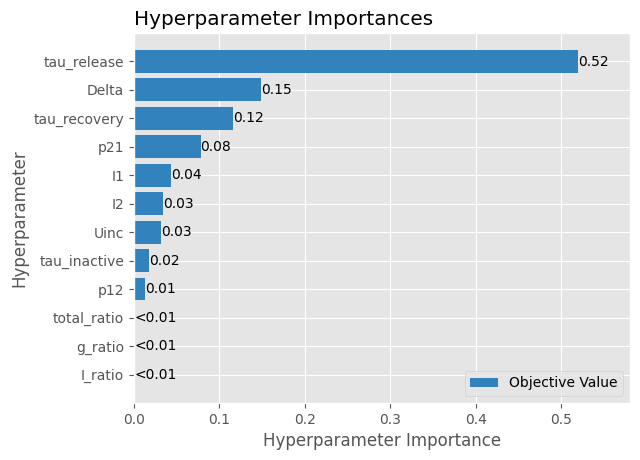

In [18]:
import optuna.visualization.matplotlib as vis

# 2. Важность каждого параметра (какой параметр больше всего влияет)
fig = vis.plot_param_importances(new_study) # temp


In [19]:
# Correlation with single parameters

optuna.visualization.plot_slice(temp_study, params=["g_ratio", "I_ratio", "total_ratio"]).show()
# optuna.visualization.plot_slice(temp_study).show()
# fig = vis.plot_slice(temp_study, target=lambda t: t.value)   
# fig.show()

/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_92842/3005559383.py:2: ExperimentalWarning:

optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.



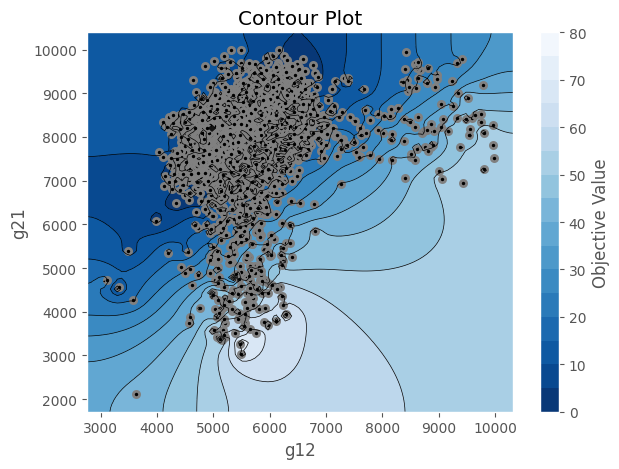

In [10]:
# Pair-wise Scatter 
fig = vis.plot_contour(temp_study, params=["p12", "p21"])#.show() 
#vis.plot_contour(temp_study, params=["I1", "I2"])#.show()

fig.set_xlabel('g12')
fig.set_ylabel('g21')
plt.tight_layout()
plt.show()

In [12]:
import optuna.visualization as vis

fig = vis.plot_parallel_coordinate(temp_study)
fig.data[0].dimensions[0].label = 'Phase difference'

# Устанавливаем свои границы для каждой оси
param_ranges = {'Phase difference':(0,80),
                'p12':(0,10000),
                'p21':(0,10000),
                'I1':(0,1000),
                'I2':(0,1000),
                'Delta':(0,300),
                'tau_release':(0,10),
                'tau_recovery':(0,1000),
                'tau_inactive':(0,100),
                'Uinc':(0,1),
                'g_ratio':(0,2),
                'I_ratio':(0,3),
                'total_ratio':(0,2)}

   
for i, dim in enumerate(fig.data[0].dimensions):
    param_name = dim.label# if not param_rename else param_rename.get(dim.label, dim.label)
    if param_name in param_ranges:
        min_val, max_val = param_ranges[param_name]
        fig.data[0].dimensions[i].range = [min_val, max_val]

for dim in fig.data[0].dimensions:
    dim.tickvals = []
    dim.ticktext = []

fig.show()

In [ ]:
tmin = 0.0
tmax = 2600 # msec
dt = 0.02
dt_f = 0.005
t = np.arange(tmin, tmax, dt)
t_f = np.arange(tmin, tmax, dt_f)
percentage = np.arange(0, 3, 0.05) # [best_params_np[2]]
frequencies = []
amplitudes = []

good_trials = sorted(not_bad_trials, key=lambda t: t.value)




# for g_trial in good_trials[:10]:
#     ok_params = g_trial.params
#     ok_params_np = np.array([ok_params[name] for name in ok_params.keys()])
#     print(ok_params_np)


# old_params_np = np.array([2249, 2138, 876, 853, 225, 3.8314141705882356, 635.5365306862744 *0.5, 15.095432365686278, 0.2738522440196079])

# just plot with best parameters, or vary some of them and save features.
for i, percent in enumerate(percentage):
    #s *= 0.01
    params = np.array(best_params_np) # , 1.0, 1.0, 500.0, 140.0

    params[4] *= percent

    rates = run_EC_model(params, t, dt)
    # spikes = run_full(params, t_f, dt_f) 
    is_oscillating_h, amplitude, frequency = get_oscillation_params(rates, dt) # 
    frequencies.append(frequency)
    amplitudes.append(amplitude)
    # print(is_oscillating_h)
    #if (i%5) == 0:
    print(i, amplitude, frequency)
    # draw(rates, t, params)
    # draw(spikes, t, params, mode='full')






0 0 0


KeyboardInterrupt: 

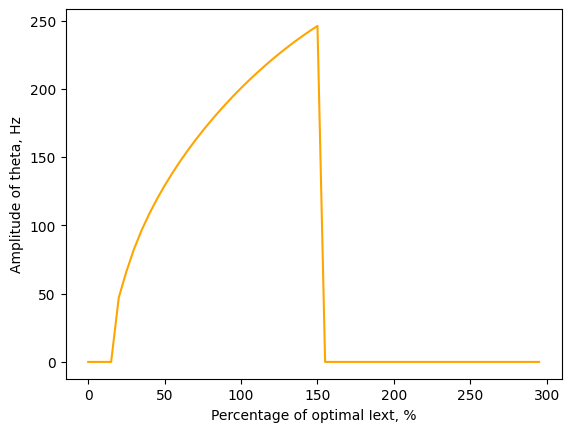

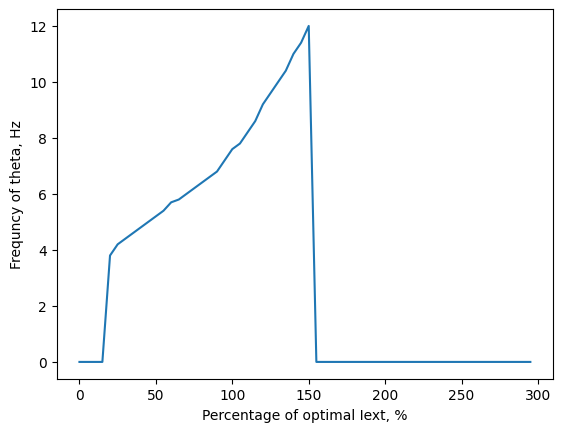

In [47]:
frequencies[12] = 5.7
amplitudes[12] = 146.7

# frequencies[31:41] = [0]*10
# amplitudes[31:41] = [0]*10

# frequencies = 14*[0].extend(frequencies[14:31].extend([0]*30))
# amplitudes = 14*[0].extend(amplitudes[14:31].extend([0]*30))


plt.grid(color = 'silver', linestyle = '--', linewidth = 0.5)
plt.xlabel("Percentage of optimal Iext, %")
plt.ylabel("Amplitude of theta, Hz")
plt.plot(percentage*100, amplitudes, 'o', color='black')
plt.show()

In [77]:
import seaborn as sns
import matplotlib.colors as mcolors
from progress.bar import IncrementalBar

tmin = 0.0
tmax = 1600 # msec
dt = 0.02
t = np.arange(tmin, tmax, dt)

Nsteps = 50

param1 = np.linspace(0,10000, Nsteps) # Iext
param2 = np.linspace(0,10000, Nsteps) # Delta
# param3 = np.linspace(0,1000, Nsteps)
# param4 = np.linspace(0,1000, Nsteps)
# param5 = np.linspace(0,300, Nsteps)

ampls = np.zeros((Nsteps, Nsteps))
freqs = np.zeros((Nsteps, Nsteps))
errors = np.zeros((Nsteps, Nsteps))


bar = IncrementalBar('Countdown', max = Nsteps**2)


for i in range(Nsteps):
    for j in range(Nsteps):

        params = np.array([param1[i], param2[j], 800, 800, 200, 3.8314141705882356, 635.5365306862744 *0.5, 15.095432365686278, 0.2738522440196079]) # S-E: 77.5955, 130.1333, 156.7755, 145.9170
        rates = run_EC_model(params, t, dt)
        
        # isoscillating = calculate_frequency(rates)
        error, ampl, freq = get_oscillation_params(rates, dt)

        if error < 500:
            # print('hilbert. ', param1[i], param2[j])
            # plot_rate(rates, t)
            ampls[i, j] = ampl
            errors[i, j] = error
            freqs[i, j] = freq
            
            
        bar.next()
        
bar.finish()

        

/var/folders/3v/mdk3s1j56l5f5tktzqjhtyr40000gn/T/ipykernel_7126/2315052875.py:39: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  errors[i, j] = error


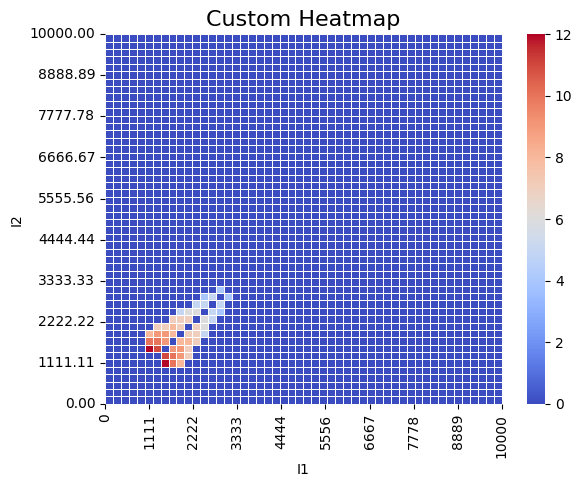

In [78]:
errors = np.where(errors==0, -50, errors)

sns.heatmap(
    np.flipud(freqs), 
    xticklabels=list(round(p1,2) for p1 in param1[::10]),  # Custom x-axis labels
    yticklabels=list(round(p2,2) for p2 in param2[::10]),  # Hide y-axis labels
    cmap="coolwarm",  # Color map
    linewidths=0.5  # Cell spacing
)

# plt.gca().set_xticks(np.linspace(0, len(range_I)-1, 10))   # 10 тиков по X

plt.gca().set(
    xticks=np.linspace(0, len(param1), 10),
    xticklabels=[f'{x:.0f}' for x in np.linspace(param1[0], param1[-1], 10)],
    yticks=np.linspace(0, len(param2), 10),
    yticklabels=[f'{y:.2f}' for y in np.linspace(param2[-1], param2[0], 10)],
    xlabel='g1',
    ylabel='g2'
)

# Add title and labels
plt.title("Custom Heatmap", fontsize=16)
plt.xlabel("I1")
plt.ylabel("I2")

plt.show()